# HDB Resale Price — Baseline Model

**Goal:** Establish a benchmark score before any feature engineering.  
**Strategy:** Minimal preprocessing → train two quick models → pick the better one as our baseline.

### Steps
1. Load & minimal clean
2. Preprocessing pipeline
3. Train/validation split
4. Model 1: Ridge Regression
5. Model 2: Random Forest
6. Compare & pick baseline
7. Generate first submission

---
## 1. Load & Minimal Clean

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

train = pd.read_csv('../../data/raw/train.csv', low_memory=False)
test  = pd.read_csv('../../data/raw/test.csv',  low_memory=False)

print(f'Train: {train.shape}  |  Test: {test.shape}')

Train: (150634, 77)  |  Test: (16737, 76)


---
## 2. Minimal Preprocessing

> **Baseline philosophy:** Do the minimum needed to make the model run. No fancy feature engineering yet — we just want a benchmark number.

In [2]:
# Drop redundant columns identified in EDA
DROP_COLS = [
    'floor_area_sqft',   # duplicate of floor_area_sqm
    'lower', 'upper', 'mid',  # duplicate of mid_storey
    'full_flat_type',    # duplicate of flat_type + flat_model
    'address',           # duplicate of block + street_name
    'Tranc_YearMonth',   # split into Tranc_Year + Tranc_Month already
]

train = train.drop(columns=[c for c in DROP_COLS if c in train.columns])
test  = test.drop(columns=[c for c in DROP_COLS if c in test.columns])

# Fill missing mall/hawker count columns with 0
fill_zero_cols = ['Hawker_Within_500m','Mall_Within_500m','Hawker_Within_1km',
                  'Mall_Within_1km','Hawker_Within_2km','Mall_Within_2km']
for col in fill_zero_cols:
    train[col] = train[col].fillna(0)
    test[col]  = test[col].fillna(0)

print('Remaining missing in train:')
print(train.isnull().sum()[train.isnull().sum() > 0])

Remaining missing in train:
Mall_Nearest_Distance    829
dtype: int64


In [ ]:
# Separate target
X = train.drop(columns=['id', 'resale_price'])
y = train['resale_price']
X_test = test.drop(columns=['id'])

# Identify numerical vs categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

print(f'Numerical features : {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')
print(f'\nCategorical cols: {cat_cols}')

Numerical features : 51
Categorical features: 17

Categorical cols: ['town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model', 'residential', 'commercial', 'market_hawker', 'multistorey_carpark', 'precinct_pavilion', 'postal', 'planning_area', 'mrt_name', 'bus_stop_name', 'pri_sch_name', 'sec_sch_name']


---
## 3. Train / Validation Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set : {X_train.shape}')
print(f'Val set   : {X_val.shape}')

Train set : (120507, 68)
Val set   : (30127, 68)


In [5]:
# Preprocessing pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

print('Preprocessor ready')

Preprocessor ready


---
## 4. Helper — Evaluation Metrics

In [6]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'  RMSE : ${rmse:>12,.0f}')
    print(f'  MAE  : ${mae:>12,.0f}')
    print(f'  R²   : {r2:>12.4f}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

---
## 5. Model 1 — Ridge Regression

In [7]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=10))
])

ridge_pipeline.fit(X_train, y_train)
ridge_pred = ridge_pipeline.predict(X_val)

ridge_scores = evaluate('Ridge Regression', y_val, ridge_pred)

--- Ridge Regression ---
  RMSE : $      58,387
  MAE  : $      43,124
  R²   :       0.8328


> **Note:** Ridge is a linear model — it gives us a floor to beat. If Random Forest can't do better, something is wrong.

---
## 6. Model 2 — Random Forest

In [8]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_val)

rf_scores = evaluate('Random Forest', y_val, rf_pred)

--- Random Forest ---
  RMSE : $      25,871
  MAE  : $      18,950
  R²   :       0.9672


---
## 7. Compare Models

                     RMSE      MAE      R2
model                                     
Ridge Regression  $58,387  $43,124  0.8328
Random Forest     $25,871  $18,950  0.9672


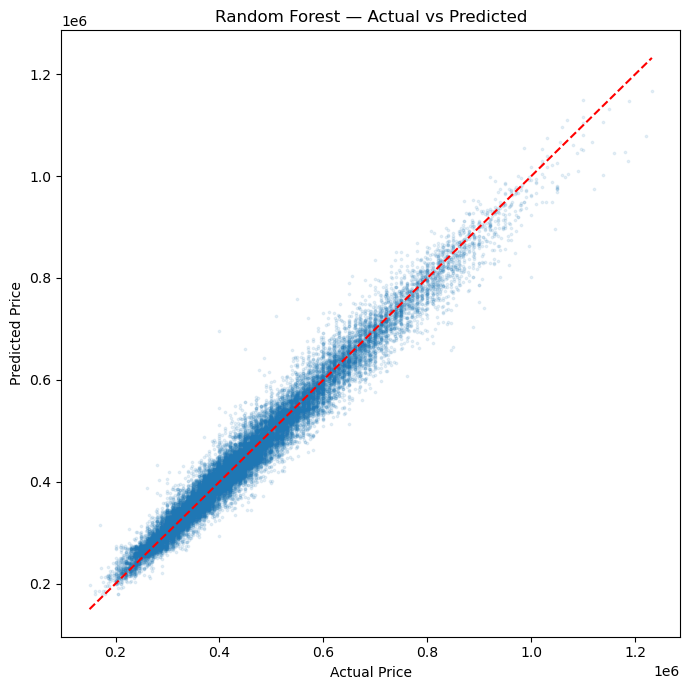

In [9]:
results = pd.DataFrame([ridge_scores, rf_scores])
results = results.set_index('model')
results['RMSE'] = results['RMSE'].map('${:,.0f}'.format)
results['MAE']  = results['MAE'].map('${:,.0f}'.format)
results['R2']   = results['R2'].map('{:.4f}'.format)
print(results)

# Visual: actual vs predicted for RF
plt.figure(figsize=(7, 7))
plt.scatter(y_val, rf_pred, alpha=0.1, s=3)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Random Forest — Actual vs Predicted')
plt.tight_layout()
plt.savefig('../../outputs/figures/baseline_actual_vs_pred.png', dpi=120)
plt.show()

> **How to read Actual vs Predicted:** Dots close to the red diagonal line = accurate predictions. Dots far above/below = over/under estimates.

---
## 8. Feature Importance (Random Forest)

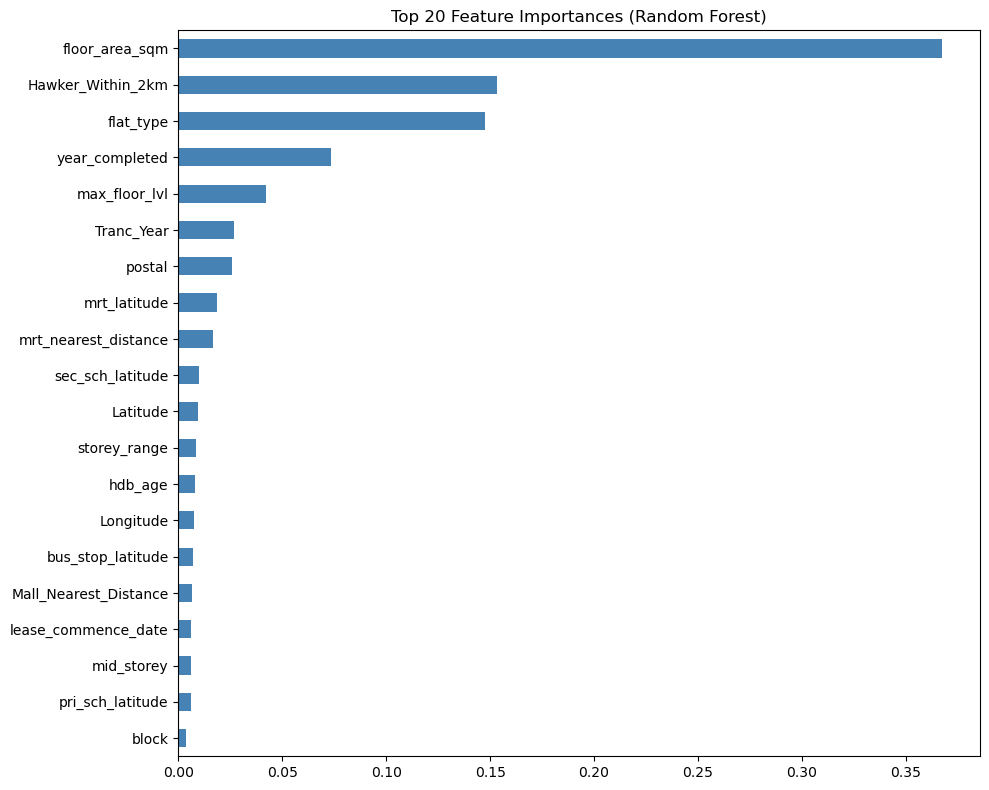

Top 10 features:
floor_area_sqm          0.367262
Hawker_Within_2km       0.153231
flat_type               0.147537
year_completed          0.073636
max_floor_lvl           0.042288
Tranc_Year              0.026970
postal                  0.025645
mrt_latitude            0.018802
mrt_nearest_distance    0.016688
sec_sch_latitude        0.009758
dtype: float64


In [10]:
# Extract feature names after preprocessing
num_feature_names = num_cols
cat_feature_names = cat_cols
all_feature_names = num_feature_names + cat_feature_names

importances = rf_pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feat_imp.head(20).plot(kind='barh', color='steelblue')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../../outputs/figures/baseline_feature_importance.png', dpi=120)
plt.show()

print('Top 10 features:')
print(feat_imp.head(10))

---
## 9. Cross-Validation (More Reliable Score)

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    rf_pipeline, X, y,
    cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

cv_rmse = -cv_scores
print(f'CV RMSE per fold : {cv_rmse.round(0)}')
print(f'CV RMSE mean     : ${cv_rmse.mean():,.0f}')
print(f'CV RMSE std      : ${cv_rmse.std():,.0f}')
print(f'\n→ Expect test RMSE around ${cv_rmse.mean():,.0f} ± ${cv_rmse.std():,.0f}')

CV RMSE per fold : [25876. 26718. 26268. 26739. 26342.]
CV RMSE mean     : $26,389
CV RMSE std      : $320

→ Expect test RMSE around $26,389 ± $320


> **Why CV score matters more than val score:** A single val split can get lucky or unlucky. 5-fold CV averages across 5 different splits — much more reliable estimate of true model performance.

---
## 10. Generate First Submission

In [12]:
# Retrain on full training data before predicting test
rf_pipeline.fit(X, y)

test_pred = rf_pipeline.predict(X_test)

submission = pd.DataFrame({
    'id': test['id'],
    'resale_price': test_pred.round(0)
})

out_path = '../../outputs/submissions/sub_v1_rf_baseline.csv'
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(submission.head(10))
print(f'\nPrediction range: ${submission["resale_price"].min():,.0f} – ${submission["resale_price"].max():,.0f}')

Saved: ../../outputs/submissions/sub_v1_rf_baseline.csv
       id  resale_price
0  114982      369925.0
1   95653      454104.0
2   40303      354743.0
3  109506      303028.0
4  100149      408196.0
5    7610      303698.0
6   61101      355405.0
7   68167      477572.0
8   65701      327314.0
9   56039      309774.0

Prediction range: $177,058 – $1,157,021


---
## 11. Baseline Summary

| | Ridge Regression | Random Forest |
|---|---|---|
| RMSE | $58,387 | $25,871 |
| MAE | $43,124 | $18,950 |
| R² | 0.8328 | 0.9672 |
| CV RMSE (5-fold) | — | $26,389 ± $320 |
| Kaggle Public Score | — | **25,943.38** |

### What to improve next
| Area | Action | Expected gain |
|---|---|---|
| Feature engineering | Add `dist_to_cbd`, `remaining_lease`, encode `town` properly | High |
| Log-transform target | Reduce impact of expensive outliers on RMSE | Medium |
| Better model | Try XGBoost / LightGBM | High |
| Hyperparameter tuning | Tune tree depth, learning rate | Medium |

### Next step
→ `notebooks/experiments/03_feature_engineering.ipynb`
